In [1]:
%cd ..

C:\Users\daanw\PycharmProjects\BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from project.models import EDMEvelynn
from project.util.data import ReplayMemoryData
from project.util.transforms import FP16Precision

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cuda.matmul.allow_fp16_reduced_precision_reduction = False
print(f"Using: {device}")

Using: cuda


In [4]:
DATA = os.path.join("checkpoints", "memory", "AdamW25e5.pt")

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # FP16Precision(),
    transforms.Normalize(0.5, 0.5),
    transforms.Pad(2),
])

In [6]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=1_000
)

In [7]:
loader = DataLoader(data, batch_size=4, shuffle=True)

In [8]:
data[1].dtype

torch.float32

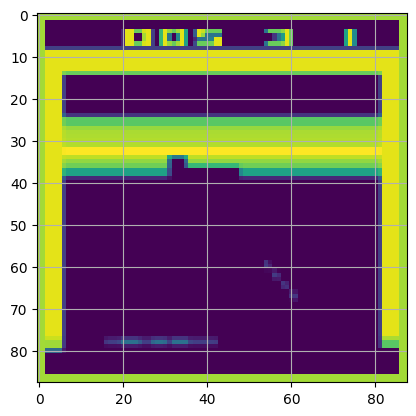

In [9]:
image = (data[50]).mean(dim=0)
plt.imshow(image)
plt.grid(None)
plt.show()

In [10]:
model = EDMEvelynn(
    img_resolution=88,
    img_channels=4,
    model_channels=128,
    channel_mult=[1, 2, 2, 2],
    attn_resolutions=[22, 11],
    lr=2e-3,
).to(device)

In [ ]:
model.train(5, loader)

Epoch 6: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [01:04<00:00,  3.88it/s]


Loss: 0.02585


Epoch 7: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [01:04<00:00,  3.88it/s]


Loss: 0.02874


Epoch 8: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [01:06<00:00,  3.77it/s]


Loss: 0.04327


Epoch 9:  93%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                 | 233/250 [01:02<00:04,  3.74it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.00it/s]


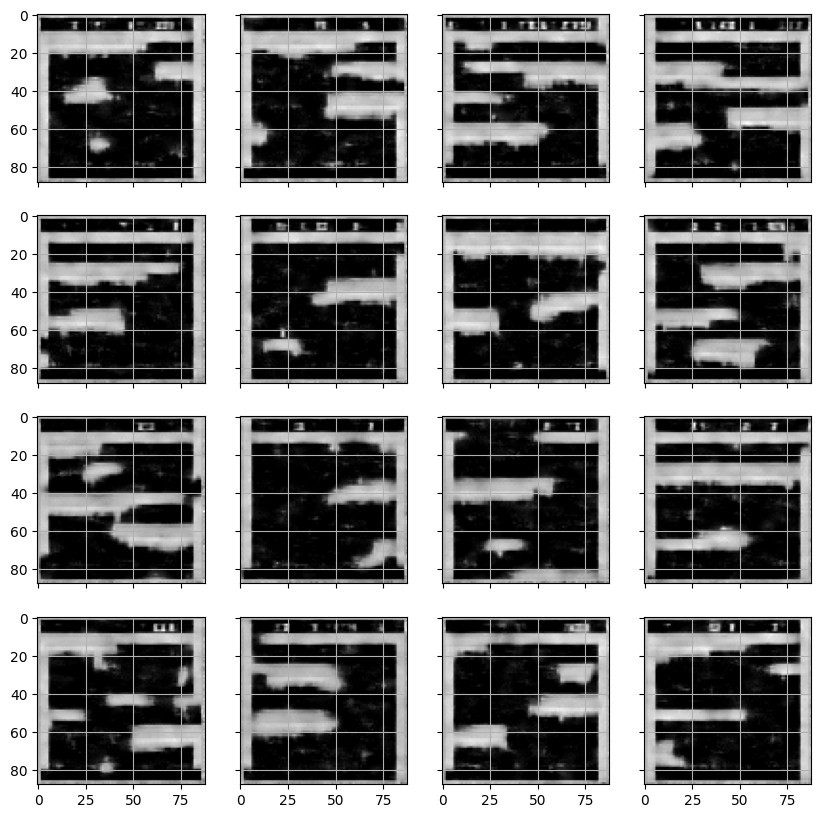

In [12]:
x = model.sample(16).to("cpu")
x = (x + 1) / 2

fig, axis = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True)
for i in range(4):
    for j in range(4):
        axis[i, j].imshow(x[i * 4 + j].mean(dim=0).clip(0, 1), cmap='grey')
        axis[i, j].grid(None)